# DataDriven_Soccer_Scouting

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from tensorflow.keras import layers, models


import warnings
warnings.filterwarnings("ignore")

import time

start_time = time.time()

## Introduction and EDA

In [2]:
df = pd.read_csv("merged_data.csv")
# Convert 'season' to a more readable format (e.g., '2020 - 2021')
df['season'] = df['season'].astype(str).str.zfill(4)
df['season'] = "20" + df['season'].str[:2] + " - 20" + df['season'].str[2:]

display(df.head())
print('\nRows: {}, Columns: {}'.format(df.shape[0], df.shape[1]))

,league,season,team,player,nation,pos,age,born,Playing Time_MP,Playing Time_Starts,...,Touches_Att 3rd,Touches_Att Pen,Touches_Def 3rd,Touches_Def Pen,Touches_Live,Touches_Mid 3rd,Touches_Touches,Height,Weight,Preferred foot
0,ENG-Premier League,2024 - 2025,Arsenal,Ben White,ENG,DF,26,1997,17,13,...,238,28,214,55,813,367,813,NaN,NaN,NaN
1,ENG-Premier League,2024 - 2025,Arsenal,Bukayo Saka,ENG,"FW,MF",22,2001,25,20,...,715,162,57,6,978,216,979,178.0,65.0,Left
2,ENG-Premier League,2024 - 2025,Arsenal,David Raya,ESP,GK,28,1995,38,38,...,0,0,1388,880,1480,92,1480,183.0,75.0,Right
3,ENG-Premier League,2024 - 2025,Arsenal,Declan Rice,ENG,MF,25,1999,35,33,...,733,81,325,82,1948,909,1948,185.0,80.0,Right
4,ENG-Premier League,2024 - 2025,Arsenal,Gabriel Magalhães,BRA,DF,26,1997,28,28,...,225,40,672,189,1873,985,1873,NaN,NaN,NaN



Rows: 4807, Columns: 117


In [3]:
#Removing rows with null values and Goalkeepers (GK)
not_null_df = df.dropna()
not_null_df = not_null_df[not_null_df['pos'] != 'GK']
print('data without null and GKs\n- rows: {} \n- columns: {}'.format(not_null_df.shape[0], not_null_df.shape[1]))
df_backup = df.copy()
df = not_null_df.copy()

data without null and GKs
- rows: 3396 
- columns: 117


In [4]:
# select all not numeric columns
not_numeric_cols = df.select_dtypes(exclude=[np.number]).columns
display(df[not_numeric_cols].head())

,league,season,team,player,nation,pos,Preferred foot
1,ENG-Premier League,2024 - 2025,Arsenal,Bukayo Saka,ENG,"FW,MF",Left
3,ENG-Premier League,2024 - 2025,Arsenal,Declan Rice,ENG,MF,Right
5,ENG-Premier League,2024 - 2025,Arsenal,Gabriel Martinelli,BRA,"FW,MF",Right
6,ENG-Premier League,2024 - 2025,Arsenal,Jakub Kiwior,POL,DF,Left
7,ENG-Premier League,2024 - 2025,Arsenal,Jurriën Timber,NED,DF,Right


In [5]:
# Convert 'Preferred foot' to binary: 1 for 'Right', 0 for 'Left'
df['right_foot'] = df['Preferred foot'].map({'Right': 1, 'Left': 0})
df.drop('Preferred foot', axis=1, inplace=True)

# Identify info columns and create a separate DataFrame for them
info_columns = ['league', 'season', 'team', 'player', 'nation', 'pos', 'born', 'age']
df_info = df[[col for col in df.columns if col.lower() in info_columns]].copy()
numeric_features = df.select_dtypes(include=[np.number]).columns
features = [col for col in numeric_features if col.lower() not in info_columns]

X = df[features].copy()

print(f"Matrix 'X' shape: {X.shape[0]} players x {X.shape[1]} statistics")

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Matrix 'X' shape: 3396 players x 109 statistics


## Similarity Search

### PCA

In [6]:
# ==========================================
# 1. PCA TRAINING (Dimensionality Reduction)
# ==========================================
print("--- Baseline Model Training: PCA ---")

# Select 10 principal components (usually enough to retain most information)
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

# Check how much information (variance) is retained after compression
varianza_totale = sum(pca.explained_variance_ratio_) * 100
print(f"Explained variance with 10 components: {varianza_totale:.2f}%")

# ==========================================
# 2. LATENT SPACE CREATION
# ==========================================
# Build a DataFrame with the new 10 mathematical coordinates
colonne_pca = [f'PC{i+1}' for i in range(X_pca.shape[1])]
df_pca = pd.DataFrame(X_pca, columns=colonne_pca)

# Merge coordinates with text info (player, team, role) saved earlier
# Reset index to guarantee alignment
df_info_reset = df_info.reset_index(drop=True)
df_latent = pd.concat([df_info_reset, df_pca], axis=1)

# ==========================================
# 3. SEARCH ENGINE (Similarity Search)
# ==========================================
def trova_simili_pca(nome_giocatore, df_latente, top_n=5):
    """
    Find the most similar players using cosine similarity on PCA components.
    """
    # Find the player case-insensitively
    giocatore_idx = df_latente[df_latente['player'].str.lower() == nome_giocatore.lower()].index

    if len(giocatore_idx) == 0:
        return f"Error: Player '{nome_giocatore}' not found in the dataset. Check the spelling."

    # If there are multiple matches, keep the first one
    idx = giocatore_idx[0]
    giocatore_reale = df_latente.loc[idx, 'player']
    squadra_reale = df_latente.loc[idx, 'team']
    print(f"\nSearching similar players for: {giocatore_reale} ({squadra_reale})")

    # Isolate target player's "DNA" (10D vector)
    giocatore_vettore = df_latente.loc[idx, colonne_pca].values.reshape(1, -1)

    # Extract all players' vectors
    tutti_i_vettori = df_latente[colonne_pca].values

    # Compute cosine similarity
    similarita = cosine_similarity(giocatore_vettore, tutti_i_vettori)[0]

    # Copy dataframe to avoid touching original
    df_latente_temp = df_latente.copy()
    df_latente_temp['Similarity_Score'] = similarita

    # Sort from most similar to least similar
    # Skip first result (same player with score 1.0)
    simili = df_latente_temp.sort_values(by='Similarity_Score', ascending=False).iloc[1:top_n+1]

    # Format score as a readable percentage
    simili['Match %'] = (simili['Similarity_Score'] * 100).round(1).astype(str) + '%'

    return simili[['player', 'age', 'team', 'pos', 'league', 'season', 'Match %']]

# Example test
target = "Kevin De Bruyne"
risultati = trova_simili_pca(target, df_latent, top_n=5)
display(risultati)

--- Baseline Model Training: PCA ---
Explained variance with 10 components: 82.22%

Searching similar players for: Kevin De Bruyne (Manchester City)


,player,age,team,pos,league,season,Match %
1994,Jonas Hofmann,31,Leverkusen,MF,GER-Bundesliga,2023 - 2024,94.6%
1365,Kevin De Bruyne,32,Manchester City,MF,ENG-Premier League,2023 - 2024,93.7%
732,Julian Brandt,28,Dortmund,MF,GER-Bundesliga,2024 - 2025,91.2%
3324,Piotr Zieliński,28,Napoli,MF,ITA-Serie A,2022 - 2023,90.9%
1041,Federico Dimarco,26,Inter,"DF,FW",ITA-Serie A,2024 - 2025,89.5%


### Deep Autoencoder

#### Mix ReLU

--- Building Deep Autoencoder (TensorFlow/Keras) ---

Training in progress...
Epoch 1/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.2540
Epoch 2/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1575
Epoch 3/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1349
Epoch 4/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1241
Epoch 5/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1163
Epoch 6/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1086
Epoch 7/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1021
Epoch 8/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0973
Epoch 9/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0936
Epoch 10/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0909
Epoch 11/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0881
Epoch 12/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0857
Epoch 13/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0835
Epoch 14/100
107/107 ━━━━━━━━━━━━━

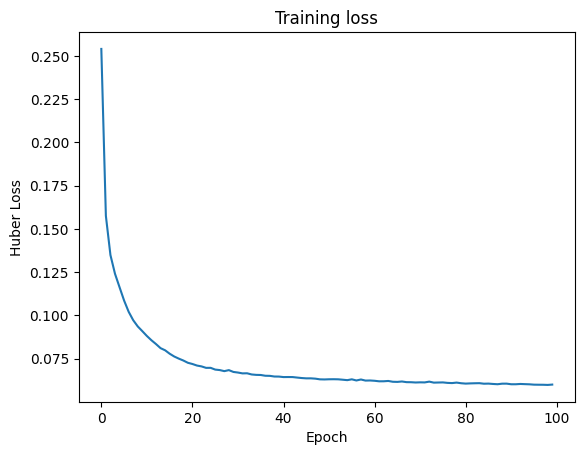


Extracting 10D DNA representation...
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [7]:
print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_scaled.shape[1]

# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================
# Input
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (ReLU + tanh mix)
encoded = layers.Dense(64, activation='relu')(input_layer)
encoded = layers.Dense(32, activation='tanh')(encoded)

# BOTTLENECK (10-dimensional latent space)
bottleneck_layer = layers.Dense(10, activation='relu', name='dna_bottleneck')(encoded)

# DECODER (Reconstruction)
decoded = layers.Dense(32, activation='tanh')(bottleneck_layer)
decoded = layers.Dense(64, activation='relu')(decoded)

# Final output (returns to original number of features, linear)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILE AND TRAIN
# ==========================================
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='huber')

print("\nTraining in progress...")
autoencoder.fit(X_scaled, X_scaled, epochs=100, batch_size=32, verbose=1)
print("Training completed!")

plot_loss = autoencoder.history.history['loss']
plt.plot(plot_loss)
plt.title("Training loss")
plt.xlabel("Epoch")
plt.ylabel("Huber Loss")
plt.show()

# ==========================================
# 3. LATENT SPACE EXTRACTION
# ==========================================
print("\nExtracting 10D DNA representation...")

encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
bottleneck = encoder.predict(X_scaled)

# ==========================================
# 4. SEARCH ENGINE (Similarity Search)
# ==========================================
colonne_ae = [f'AE_{i+1}' for i in range(10)]
df_ae_mix_relu = pd.DataFrame(bottleneck, columns=colonne_ae)
df_latent_ae_mix_relu = pd.concat([df_info_reset, df_ae_mix_relu], axis=1)

#### Mix Tanh

--- Building Deep Autoencoder (TensorFlow/Keras) ---

Training in progress...
Epoch 1/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.2490
Epoch 2/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1579
Epoch 3/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1370
Epoch 4/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1255
Epoch 5/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1175
Epoch 6/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1122
Epoch 7/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1079
Epoch 8/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1047
Epoch 9/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1008
Epoch 10/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0973
Epoch 11/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0934
Epoch 12/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0902
Epoch 13/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0871
Epoch 14/100
107/107 ━━━━━━━━━━━━━

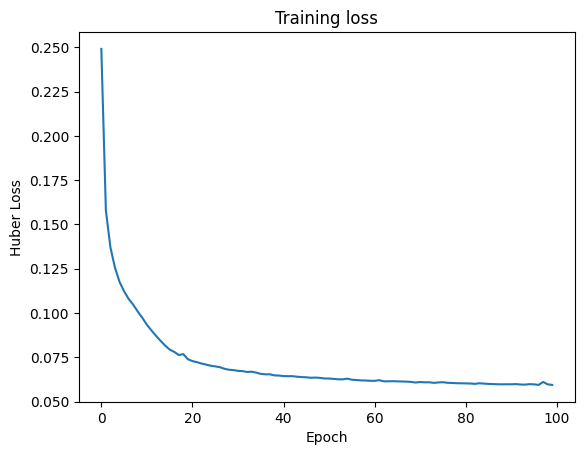


Extracting 10D DNA representation...
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [8]:
print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_scaled.shape[1]

# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================
# Input
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (ReLU + tanh mix)
encoded = layers.Dense(64, activation='relu')(input_layer)
encoded = layers.Dense(32, activation='tanh')(encoded)

# BOTTLENECK (10-dimensional latent space)
bottleneck_layer = layers.Dense(10, activation='tanh', name='dna_bottleneck')(encoded)

# DECODER (Reconstruction)
decoded = layers.Dense(32, activation='tanh')(bottleneck_layer)
decoded = layers.Dense(64, activation='relu')(decoded)

# Final output (returns to original number of features, linear)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILE AND TRAIN
# ==========================================
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='huber')

print("\nTraining in progress...")
autoencoder.fit(X_scaled, X_scaled, epochs=100, batch_size=32, verbose=1)
print("Training completed!")

plot_loss = autoencoder.history.history['loss']
plt.plot(plot_loss)
plt.title("Training loss")
plt.xlabel("Epoch")
plt.ylabel("Huber Loss")
plt.show()

# ==========================================
# 3. LATENT SPACE EXTRACTION
# ==========================================
print("\nExtracting 10D DNA representation...")

encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
bottleneck = encoder.predict(X_scaled)

# ==========================================
# 4. SEARCH ENGINE (Similarity Search)
# ==========================================
colonne_ae = [f'AE_{i+1}' for i in range(10)]
df_ae_mix_tanh = pd.DataFrame(bottleneck, columns=colonne_ae)
df_latent_ae_mix_tanh = pd.concat([df_info_reset, df_ae_mix_tanh], axis=1)

#### Relu

--- Building Deep Autoencoder (TensorFlow/Keras) ---

Training in progress...
Epoch 1/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.2581
Epoch 2/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1598
Epoch 3/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1364
Epoch 4/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1223
Epoch 5/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1134
Epoch 6/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1049
Epoch 7/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0992
Epoch 8/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0946
Epoch 9/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0906
Epoch 10/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0882
Epoch 11/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0867
Epoch 12/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0857
Epoch 13/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0844
Epoch 14/100
107/107 ━━━━━━━━━━━━━

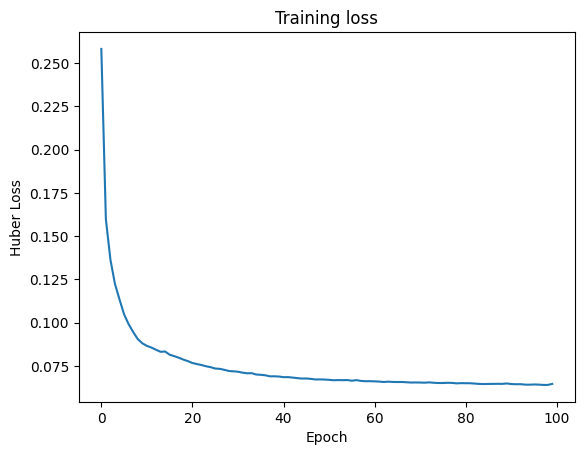


Extracting 10D DNA representation...
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [9]:
print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_scaled.shape[1] 

# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================
# Input
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (ReLU compression)
encoded = layers.Dense(64, activation='relu')(input_layer)
encoded = layers.Dense(32, activation='relu')(encoded)

# BOTTLENECK (10-dimensional latent space)
bottleneck_layer = layers.Dense(10, activation='relu', name='dna_bottleneck')(encoded)

# DECODER (Reconstruction)
decoded = layers.Dense(32, activation='relu')(bottleneck_layer)
decoded = layers.Dense(64, activation='relu')(decoded)

# Final output (returns to original number of columns, linear)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILE AND TRAIN
# ==========================================
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='huber')

print("\nTraining in progress...")
autoencoder.fit(X_scaled, X_scaled, epochs=100, batch_size=32, verbose=1)
print("Training completed!")

plot_loss = autoencoder.history.history['loss']
plt.plot(plot_loss)
plt.title('Training loss')
plt.xlabel('Epoch')
plt.ylabel('Huber Loss')
plt.show()

# ==========================================
# 3. LATENT SPACE EXTRACTION
# ==========================================
print("\nExtracting 10D DNA representation...")

encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
bottleneck = encoder.predict(X_scaled)

# ==========================================
# 4. SEARCH ENGINE (Similarity Search)
# ==========================================
colonne_ae = [f'AE_{i+1}' for i in range(10)]
df_ae_relu = pd.DataFrame(bottleneck, columns=colonne_ae)
df_latent_ae_relu = pd.concat([df_info_reset, df_ae_relu], axis=1)

#### Tanh

--- Building Deep Autoencoder (TensorFlow/Keras) ---

Training in progress...
Epoch 1/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2309
Epoch 2/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1500
Epoch 3/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1280
Epoch 4/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1159
Epoch 5/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1078
Epoch 6/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1017
Epoch 7/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0977
Epoch 8/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0952
Epoch 9/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0927
Epoch 10/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0913
Epoch 11/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0897
Epoch 12/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0885
Epoch 13/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0876
Epoch 14/200
107/107 ━━━━━━━━━━━━━

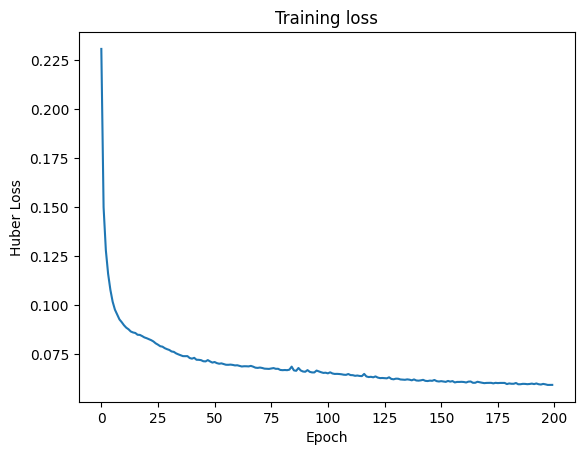


Extracting 10D DNA representation...
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [10]:
print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_scaled.shape[1] 

# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================
# Input
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (tanh compression)
encoded = layers.Dense(64, activation='tanh')(input_layer)
encoded = layers.Dense(32, activation='tanh')(encoded)

# BOTTLENECK (10-dimensional latent space)
bottleneck_layer = layers.Dense(10, activation='tanh', name='dna_bottleneck')(encoded)

# DECODER (Reconstruction)
decoded = layers.Dense(32, activation='tanh')(bottleneck_layer)
decoded = layers.Dense(64, activation='tanh')(decoded)

# Final output (returns to original number of columns, linear)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILE AND TRAIN
# ==========================================
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='huber')

print("\nTraining in progress...")
autoencoder.fit(X_scaled, X_scaled, epochs=200, batch_size=32, verbose=1)
print("Training completed!")

plot_loss = autoencoder.history.history['loss']
plt.plot(plot_loss)
plt.title('Training loss')
plt.xlabel('Epoch')
plt.ylabel('Huber Loss')
plt.show()

# ==========================================
# 3. LATENT SPACE EXTRACTION
# ==========================================
print("\nExtracting 10D DNA representation...")

encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
bottleneck = encoder.predict(X_scaled)

# ==========================================
# 4. SEARCH ENGINE (Similarity Search)
# ==========================================
colonne_ae = [f'AE_{i+1}' for i in range(10)]
df_ae_tanh = pd.DataFrame(bottleneck, columns=colonne_ae)
df_latent_ae_tanh = pd.concat([df_info_reset, df_ae_tanh], axis=1)

#### ReLU with dropout

--- Building Deep Autoencoder (TensorFlow/Keras) ---

Training in progress...
Epoch 1/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.2551
Epoch 2/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1802
Epoch 3/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1653
Epoch 4/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1579
Epoch 5/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1531
Epoch 6/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1483
Epoch 7/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1438
Epoch 8/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1408
Epoch 9/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1371
Epoch 10/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1347
Epoch 11/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1324
Epoch 12/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1320
Epoch 13/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1303
Epoch 14/300
107/107 ━━━━━━━━━━━━━

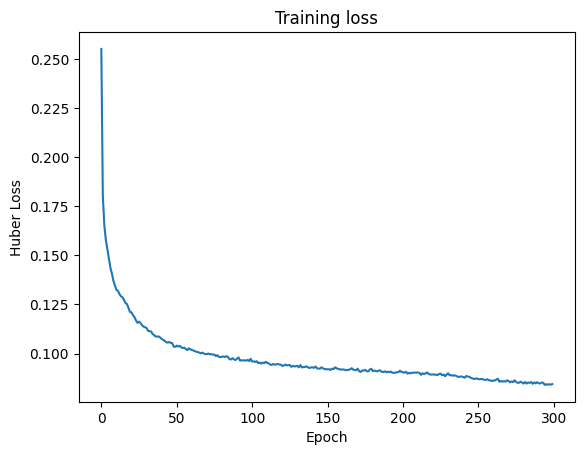


Extracting 10D DNA representation...
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [11]:
print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_scaled.shape[1] 

# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================
# Input
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (ReLU compression)
encoded = layers.Dense(128, activation='relu')(input_layer)
encoded = layers.Dropout(0.2)(encoded)
encoded = layers.Dense(64, activation='relu')(encoded)
encoded = layers.Dense(32, activation='relu')(encoded)

# BOTTLENECK (10-dimensional latent space)
bottleneck_layer = layers.Dense(10, activation='relu', name='dna_bottleneck')(encoded)

# DECODER (Reconstruction)
decoded = layers.Dense(32, activation='relu')(bottleneck_layer)
decoded = layers.Dense(64, activation='relu')(decoded)
decoded = layers.Dropout(0.2)(decoded)
decoded = layers.Dense(128, activation='relu')(decoded)

# Final output (returns to original number of columns, linear)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILE AND TRAIN
# ==========================================
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='huber')

print("\nTraining in progress...")
autoencoder.fit(X_scaled, X_scaled, epochs=300, batch_size=32, verbose=1)
print("Training completed!")

plot_loss = autoencoder.history.history['loss']
plt.plot(plot_loss)
plt.title('Training loss')
plt.xlabel('Epoch')
plt.ylabel('Huber Loss')
plt.show()

# ==========================================
# 3. LATENT SPACE EXTRACTION
# ==========================================
print("\nExtracting 10D DNA representation...")

encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
bottleneck = encoder.predict(X_scaled)

# ==========================================
# 4. SEARCH ENGINE (Similarity Search)
# ==========================================
colonne_ae = [f'AE_{i+1}' for i in range(10)]
df_ae_relu_dropout = pd.DataFrame(bottleneck, columns=colonne_ae)
df_latent_ae_relu_dropout = pd.concat([df_info_reset, df_ae_relu_dropout], axis=1)

#### Tanh with dropout

--- Building Deep Autoencoder (TensorFlow/Keras) ---

Training in progress...
Epoch 1/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.2194
Epoch 2/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1521
Epoch 3/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1367
Epoch 4/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1318
Epoch 5/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1258
Epoch 6/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1214
Epoch 7/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1185
Epoch 8/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1164
Epoch 9/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1140
Epoch 10/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1122
Epoch 11/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1108
Epoch 12/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1099
Epoch 13/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1085
Epoch 14/300
107/107 ━━━━━━━━━━━━━

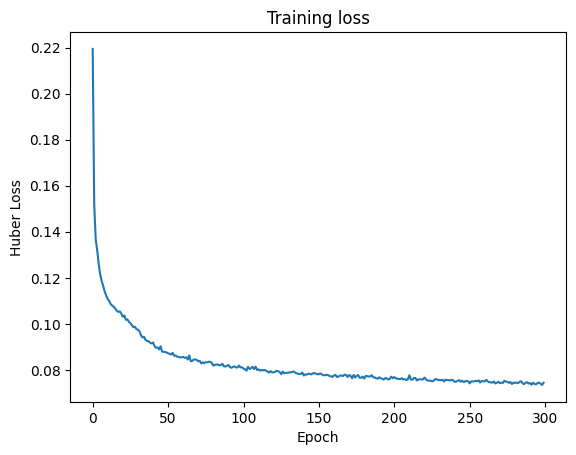


Extracting 10D DNA representation...
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [12]:
print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_scaled.shape[1] 

# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================
# Input
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (tanh compression)
encoded = layers.Dense(128, activation='tanh')(input_layer)
encoded = layers.Dropout(0.2)(encoded)
encoded = layers.Dense(64, activation='tanh')(encoded)
encoded = layers.Dense(32, activation='tanh')(encoded)

# BOTTLENECK (10-dimensional latent space)
bottleneck_layer = layers.Dense(10, activation='tanh', name='dna_bottleneck')(encoded)

# DECODER (Reconstruction)
decoded = layers.Dense(32, activation='tanh')(bottleneck_layer)
decoded = layers.Dense(64, activation='tanh')(decoded)
decoded = layers.Dropout(0.2)(decoded)
decoded = layers.Dense(128, activation='tanh')(decoded)

# Final output (returns to original number of columns, linear)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILE AND TRAIN
# ==========================================
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='huber')

print("\nTraining in progress...")
autoencoder.fit(X_scaled, X_scaled, epochs=300, batch_size=32, verbose=1)
print("Training completed!")

plot_loss = autoencoder.history.history['loss']
plt.plot(plot_loss)
plt.title('Training loss')
plt.xlabel('Epoch')
plt.ylabel('Huber Loss')
plt.show()

# ==========================================
# 3. LATENT SPACE EXTRACTION
# ==========================================
print("\nExtracting 10D DNA representation...")

encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
bottleneck = encoder.predict(X_scaled)

# ==========================================
# 4. SEARCH ENGINE (Similarity Search)
# ==========================================
colonne_ae = [f'AE_{i+1}' for i in range(10)]
df_ae_tanh_dropout = pd.DataFrame(bottleneck, columns=colonne_ae)
df_latent_ae_tanh_dropout = pd.concat([df_info_reset, df_ae_tanh_dropout], axis=1)

#### ReLU + Tanh bottleneck with dropout

--- Building Deep Autoencoder (TensorFlow/Keras) ---

Training in progress...
Epoch 1/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.3009
Epoch 2/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1955
Epoch 3/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1792
Epoch 4/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1706
Epoch 5/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1648
Epoch 6/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1584
Epoch 7/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1539
Epoch 8/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1488
Epoch 9/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1450
Epoch 10/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1425
Epoch 11/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1395
Epoch 12/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1376
Epoch 13/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1359
Epoch 14/100
107/107 ━━━━━━━━━━━━━

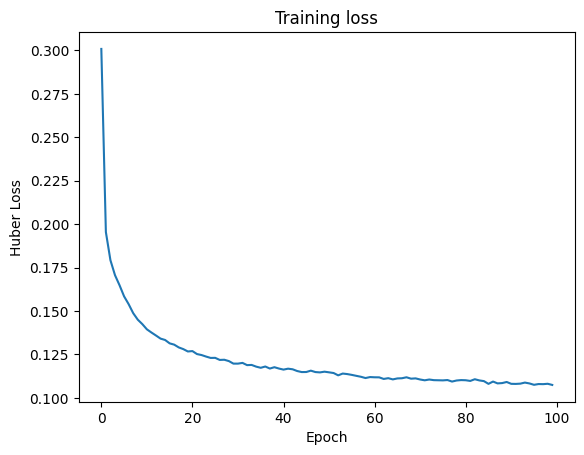


Extracting 10D DNA representation...
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [13]:
print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_scaled.shape[1] 

# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================
# Input
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (ReLU compression)
encoded = layers.Dense(64, activation='relu')(input_layer)
encoded = layers.Dropout(0.2)(encoded)
encoded = layers.Dense(32, activation='relu')(encoded)

# BOTTLENECK (10-dimensional latent space, bounded by tanh)
bottleneck_layer = layers.Dense(10, activation='tanh', name='dna_bottleneck')(encoded)

# DECODER (Reconstruction)
decoded = layers.Dense(32, activation='relu')(bottleneck_layer)
decoded = layers.Dense(64, activation='relu')(decoded)
decoded = layers.Dropout(0.2)(decoded)

# Final output (returns to original number of columns, linear)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILE AND TRAIN
# ==========================================
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='huber')

print("\nTraining in progress...")
autoencoder.fit(X_scaled, X_scaled, epochs=100, batch_size=32, verbose=1)
print("Training completed!")

plot_loss = autoencoder.history.history['loss']
plt.plot(plot_loss)
plt.title('Training loss')
plt.xlabel('Epoch')
plt.ylabel('Huber Loss')
plt.show()

# ==========================================
# 3. LATENT SPACE EXTRACTION
# ==========================================
print("\nExtracting 10D DNA representation...")

encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
bottleneck = encoder.predict(X_scaled)

# ==========================================
# 4. SEARCH ENGINE (Similarity Search)
# ==========================================
colonne_ae = [f'AE_{i+1}' for i in range(10)]
df_ae_relu_tanh_btn = pd.DataFrame(bottleneck, columns=colonne_ae)
df_latent_ae_relu_tanh_btn = pd.concat([df_info_reset, df_ae_relu_tanh_btn], axis=1)

#### Testing Autoencoder

##### Similarity Functions

In [14]:
def trova_simili_ae(nome_giocatore, stagione_giocatore, df_latente, top_n=5, max_age=None, season_filter=None, same_position=False, same_league=False, same_preferred_foot=False):
    # Find player index by name and season
    mask_target = (
        (df_latente['player'].str.lower() == nome_giocatore.lower())
        & (df_latente['season'] == stagione_giocatore)
    )
    giocatore_idx = df_latente[mask_target].index

    if len(giocatore_idx) == 0:
        return "Player not found in the database."

    idx = giocatore_idx[0]
    giocatore_reale = df_latente.loc[idx, 'player']
    squadra_reale = df_latente.loc[idx, 'team']
    stagione = df_latente.loc[idx, 'season']
    ruolo = df_latente.loc[idx, 'pos']

    print(f"\n[AUTOENCODER] Searching similar players for: {giocatore_reale} ({squadra_reale} - {stagione})")

    # Extract target player's 10 latent values
    giocatore_vettore = df_latente.loc[idx, colonne_ae].values.reshape(1, -1)
    # Extract all players' latent values
    tutti_i_vettori = df_latente[colonne_ae].values

    # Compute cosine similarity
    similarita = cosine_similarity(giocatore_vettore, tutti_i_vettori)[0]

    # Assign scores
    df_latente_temp = df_latente.copy()
    df_latente_temp['Similarity_Score'] = similarita

    # Exclude target player from results
    df_latente_temp = df_latente_temp.drop(index=idx)

    # Optional age filter
    if max_age is not None:
        df_latente_temp = df_latente_temp[df_latente_temp['age'] <= max_age]

    # Optional season filter
    if season_filter is not None:
        df_latente_temp = df_latente_temp[df_latente_temp['season'] == season_filter]

    # Optional position filter
    if same_position:
        df_latente_temp = df_latente_temp[df_latente_temp['pos'] == ruolo]

    # Optional league filter
    if same_league:
        df_latente_temp = df_latente_temp[df_latente_temp['league'] == df_latente.loc[idx, 'league']]

    # Optional preferred-foot filter
    if same_preferred_foot:
        df_latente_temp = df_latente_temp[df_latente_temp['preferred_foot'] == df_latente.loc[idx, 'preferred_foot']]

    df_latente_temp = df_latente_temp[df_latente_temp['player'] != nome_giocatore]

    # Sort from most similar to least similar
    simili = df_latente_temp.sort_values(by='Similarity_Score', ascending=False).head(top_n).copy()

    # Format score as a readable percentage
    simili['Match %'] = (simili['Similarity_Score'] * 100).round(1).astype(str) + '%'

    colonne_output = ['player', 'age', 'team', 'pos', 'league', 'season', 'Match %']
    return simili[colonne_output]

In [15]:
def trova_simili_ensemble(
    nome_giocatore,
    stagione_giocatore,
    df_latente_a=df_latent_ae_relu_tanh_btn,
    df_latente_b=df_latent_ae_tanh_dropout,
    df_latente_c=df_latent_ae_tanh,
    top_n=5,
    max_age=None,
    season_filter=None,
    same_position=False,
    same_league=False
):
    # Target player
    mask_target = (
        (df_latente_a['player'].str.lower() == nome_giocatore.lower())
        & (df_latente_a['season'] == stagione_giocatore)
    )
    giocatore_idx = df_latente_a[mask_target].index

    if len(giocatore_idx) == 0:
        return "Player not found in the database."

    idx = giocatore_idx[0]
    giocatore_reale = df_latente_a.loc[idx, 'player']
    squadra_reale = df_latente_a.loc[idx, 'team']
    stagione = df_latente_a.loc[idx, 'season']
    ruolo = df_latente_a.loc[idx, 'pos']
    league = df_latente_a.loc[idx, 'league']

    print(f"\n[ENSEMBLE] Searching similar players for: {giocatore_reale} ({squadra_reale} - {stagione})")

    # Average cosine similarity from the three latent spaces
    vettore_a = df_latente_a.loc[idx, colonne_ae].values.reshape(1, -1)
    vettore_b = df_latente_b.loc[idx, colonne_ae].values.reshape(1, -1)
    vettore_c = df_latente_c.loc[idx, colonne_ae].values.reshape(1, -1)
    sim_a = cosine_similarity(vettore_a, df_latente_a[colonne_ae].values)[0]
    sim_b = cosine_similarity(vettore_b, df_latente_b[colonne_ae].values)[0]
    sim_c = cosine_similarity(vettore_c, df_latente_c[colonne_ae].values)[0]
    sim_ensemble = (sim_a + sim_b + sim_c) / 3

    df_temp = df_latente_a.copy()
    df_temp['Similarity_Score'] = sim_ensemble
    df_temp = df_temp.drop(index=idx)

    if max_age is not None:
        df_temp = df_temp[df_temp['age'] <= max_age]

    if season_filter is not None:
        df_temp = df_temp[df_temp['season'] == season_filter]

    if same_position:
        df_temp = df_temp[df_temp['pos'] == ruolo]

    if same_league:
        df_temp = df_temp[df_temp['league'] == league]

    df_temp = df_temp[df_temp['player'] != nome_giocatore]

    simili = df_temp.sort_values(by='Similarity_Score', ascending=False).head(top_n).copy()
    simili['Match %'] = (simili['Similarity_Score'] * 100).round(1).astype(str) + '%'

    return simili[['player', 'age', 'team', 'pos', 'league', 'season', 'Match %']]

##### Testing

###### Single Testing

In [16]:
# ==========================================
# 5. TEST THE MODEL
# ==========================================
target_player = "Riccardo Orsolini"
target_season = "2024 - 2025"
max_age = None

models_to_test = {
    'Relu': df_latent_ae_relu,
    'Tanh': df_latent_ae_tanh,
    'Mix ReLU': df_latent_ae_mix_relu,
    'Mix Tanh': df_latent_ae_mix_tanh,
    'ReLU + Dropout': df_latent_ae_relu_dropout,
    'Tanh + Dropout': df_latent_ae_tanh_dropout,
    'ReLU + Tanh bottleneck': df_latent_ae_relu_tanh_btn,
}

for model_name, model_df in models_to_test.items():
    print(f"\n===== Model: {model_name} =====")
    risultati_ae = trova_simili_ae(
        nome_giocatore=target_player,
        stagione_giocatore=target_season,
        df_latente=model_df,
        top_n=5,
        max_age=max_age,
        season_filter=None,
        same_position=True
    )
    display(risultati_ae)

print("\n===== Model: Ensemble =====")
risultati_ensemble = trova_simili_ensemble(
    nome_giocatore=target_player,
    stagione_giocatore=target_season,
    top_n=5,
    max_age=max_age,
    season_filter=None,
    same_position=True,
    same_league=False
)
display(risultati_ensemble)


===== Model: Relu =====

[AUTOENCODER] Searching similar players for: Riccardo Orsolini (Bologna - 2024 - 2025)


,player,age,team,pos,league,season,Match %
287,Julián Álvarez,24,Atlético Madrid,FW,ESP-La Liga,2024 - 2025,99.4%
1736,Georges Mikautadze,22,Metz,FW,FRA-Ligue 1,2023 - 2024,99.2%
1791,Kylian Mbappé,24,Paris S-G,FW,FRA-Ligue 1,2023 - 2024,99.1%
2040,Serhou Guirassy,27,Stuttgart,FW,GER-Bundesliga,2023 - 2024,99.1%
832,Jonathan Burkardt,24,Mainz 05,FW,GER-Bundesliga,2024 - 2025,99.0%



===== Model: Tanh =====

[AUTOENCODER] Searching similar players for: Riccardo Orsolini (Bologna - 2024 - 2025)


,player,age,team,pos,league,season,Match %
1736,Georges Mikautadze,22,Metz,FW,FRA-Ligue 1,2023 - 2024,95.0%
1063,Randal Kolo Muani,25,Juventus,FW,ITA-Serie A,2024 - 2025,90.1%
752,Omar Marmoush,25,Eint Frankfurt,FW,GER-Bundesliga,2024 - 2025,89.8%
1479,Álex Berenguer,28,Athletic Club,FW,ESP-La Liga,2023 - 2024,89.5%
1711,Alexandre Lacazette,32,Lyon,FW,FRA-Ligue 1,2023 - 2024,88.2%



===== Model: Mix ReLU =====

[AUTOENCODER] Searching similar players for: Riccardo Orsolini (Bologna - 2024 - 2025)


...

,player,age,team,pos,league,season,Match %
2827,Ibrahima Koné,23,Lorient,FW,FRA-Ligue 1,2022 - 2023,92.1%
1736,Georges Mikautadze,22,Metz,FW,FRA-Ligue 1,2023 - 2024,91.7%
273,Toni Martínez,27,Alavés,FW,ESP-La Liga,2024 - 2025,90.6%
2312,Domenico Berardi,28,Sassuolo,FW,ITA-Serie A,2023 - 2024,90.5%
585,Arnaud Nordin,26,Montpellier,FW,FRA-Ligue 1,2024 - 2025,89.6%



===== Model: ReLU + Tanh bottleneck =====

[AUTOENCODER] Searching similar players for: Riccardo Orsolini (Bologna - 2024 - 2025)


,player,age,team,pos,league,season,Match %
1736,Georges Mikautadze,22,Metz,FW,FRA-Ligue 1,2023 - 2024,90.5%
752,Omar Marmoush,25,Eint Frankfurt,FW,GER-Bundesliga,2024 - 2025,86.1%
365,Fábio Silva,22,Las Palmas,FW,ESP-La Liga,2024 - 2025,83.9%
3153,Niclas Füllkrug,29,Werder Bremen,FW,GER-Bundesliga,2022 - 2023,81.3%
1479,Álex Berenguer,28,Athletic Club,FW,ESP-La Liga,2023 - 2024,81.3%



===== Model: Ensemble =====

[ENSEMBLE] Searching similar players for: Riccardo Orsolini (Bologna - 2024 - 2025)


,player,age,team,pos,league,season,Match %
1736,Georges Mikautadze,22,Metz,FW,FRA-Ligue 1,2023 - 2024,92.4%
1479,Álex Berenguer,28,Athletic Club,FW,ESP-La Liga,2023 - 2024,86.4%
365,Fábio Silva,22,Las Palmas,FW,ESP-La Liga,2024 - 2025,85.8%
1063,Randal Kolo Muani,25,Juventus,FW,ITA-Serie A,2024 - 2025,81.2%
1711,Alexandre Lacazette,32,Lyon,FW,FRA-Ligue 1,2023 - 2024,80.4%


###### Bulk Testing

In [17]:
# Single table with all results (target player x model)
target = ["Kevin De Bruyne", "Alessandro Bastoni", "Manuel Locatelli", "Andrea Pinamonti", 'Erling Haaland', "Xavi Simons", "Riccardo Orsolini"]
same_position = [False, False, False, False, False, False, False]
max_age = 23

target_same_position = dict(zip(target, same_position))
all_results = []

for giocatore in target:
    for model_name, model_df in models_to_test.items():
        res = trova_simili_ae(
            nome_giocatore=giocatore,
            stagione_giocatore=target_season,
            df_latente=model_df,
            top_n=5,
            max_age=max_age,
            season_filter=None,
            same_position=target_same_position[giocatore],
            same_league=False,
            same_preferred_foot=False
        )

        if isinstance(res, pd.DataFrame):
            res = res.copy()
            res["target_player"] = giocatore
            res["target_season"] = target_season
            res["model_used"] = model_name
            res["rank"] = range(1, len(res) + 1)
            all_results.append(res)

    # Add the ensemble result as well
    res_ensemble = trova_simili_ensemble(
        nome_giocatore=giocatore,
        stagione_giocatore=target_season,
        top_n=5,
        max_age=max_age,
        season_filter=None,
        same_position=target_same_position[giocatore],
        same_league=False
    )

    if isinstance(res_ensemble, pd.DataFrame):
        res_ensemble = res_ensemble.copy()
        res_ensemble["target_player"] = giocatore
        res_ensemble["target_season"] = target_season
        res_ensemble["model_used"] = "Ensemble"
        res_ensemble["rank"] = range(1, len(res_ensemble) + 1)
        all_results.append(res_ensemble)

# Final grouped DataFrame
grouped_results_table = pd.concat(all_results, ignore_index=True)

# Column order for readability
grouped_results_table = (
    grouped_results_table[
        ["target_player", "target_season", "model_used", "rank", "player", "age", "team", "pos", "league", "season", "Match %"]
    ]
    .sort_values(["target_player", "model_used", "rank"])
    .reset_index(drop=True)
)

display(grouped_results_table)


[AUTOENCODER] Searching similar players for: Kevin De Bruyne (Manchester City - 2024 - 2025)

[AUTOENCODER] Searching similar players for: Kevin De Bruyne (Manchester City - 2024 - 2025)

[AUTOENCODER] Searching similar players for: Kevin De Bruyne (Manchester City - 2024 - 2025)

[AUTOENCODER] Searching similar players for: Kevin De Bruyne (Manchester City - 2024 - 2025)

[AUTOENCODER] Searching similar players for: Kevin De Bruyne (Manchester City - 2024 - 2025)

[AUTOENCODER] Searching similar players for: Kevin De Bruyne (Manchester City - 2024 - 2025)

[AUTOENCODER] Searching similar players for: Kevin De Bruyne (Manchester City - 2024 - 2025)

[ENSEMBLE] Searching similar players for: Kevin De Bruyne (Manchester City - 2024 - 2025)

[AUTOENCODER] Searching similar players for: Alessandro Bastoni (Inter - 2024 - 2025)

[AUTOENCODER] Searching similar players for: Alessandro Bastoni (Inter - 2024 - 2025)

[AUTOENCODER] Searching similar players for: Alessandro Bastoni (Inter - 202

,target_player,target_season,model_used,rank,player,age,team,pos,league,season,Match %
0,Alessandro Bastoni,2024 - 2025,Ensemble,1,Jules Koundé,23,Barcelona,DF,ESP-La Liga,2022 - 2023,88.3%
1,Alessandro Bastoni,2024 - 2025,Ensemble,2,Facundo Medina,23,Lens,DF,FRA-Ligue 1,2022 - 2023,83.6%
2,Alessandro Bastoni,2024 - 2025,Ensemble,3,Riccardo Calafiori,21,Bologna,DF,ITA-Serie A,2023 - 2024,83.2%
3,Alessandro Bastoni,2024 - 2025,Ensemble,4,Piero Hincapié,22,Leverkusen,DF,GER-Bundesliga,2024 - 2025,80.6%
4,Alessandro Bastoni,2024 - 2025,Ensemble,5,Matteo Ruggeri,21,Atalanta,DF,ITA-Serie A,2023 - 2024,79.8%
...,...,...,...,...,...,...,...,...,...,...,...
275,Xavi Simons,2024 - 2025,Tanh + Dropout,1,Matìas Soulé,21,Roma,"MF,DF",ITA-Serie A,2024 - 2025,95.6%
276,Xavi Simons,2024 - 2025,Tanh + Dropout,2,Callum Hudson-Odoi,22,Nott'ham Forest,"FW,MF",ENG-Premier League,2023 - 2024,93.9%
277,Xavi Simons,2024 - 2025,Tanh + Dropout,3,Takefusa Kubo,22,Real Sociedad,"FW,MF",ESP-La Liga,2023 - 2024,93.5%
278,Xavi Simons,2024 - 2025,Tanh + Dropout,4,Yan Couto,20,Girona,"DF,MF",ESP-La Liga,2022 - 2023,92.4%


In [18]:
grouped_results_table.to_csv("grouped_results_table.csv", index=False)

#### Choice explanation

To maximize accuracy and handle tactical nuances such as hybrid roles and statistical outliers, the final pipeline uses an ensemble of two autoencoders and averages their cosine similarity scores.

* Model A: the specialist (ReLU encoder with tanh bottleneck)
    * Architecture: Standard

            Input -> 64 -> Dropout -> 32 -> 10 -> 32 -> 64 -> Dropout -> Output.

    * Encoder activation: ReLU. This can create sparse intermediate representations and keep the model focused on the strongest signals.
    * Bottleneck activation: tanh. This constrains the 10D latent space to [-1, 1], which is compatible with cosine similarity.
    * Epochs & batch size: 100 epochs, batch size 32.

* Model B: the holistic model (tanh network with dropout)
    * Architecture: Deeper layers to capture highly non-linear and complex tactical relationships.

            Input -> 128 -> Dropout -> 64 -> 32 -> 10 -> 32 -> 64 -> Dropout -> 128 -> Output

    * Activation: tanh throughout. This keeps the latent space bounded and preserves sign information in the compressed representation.
    * Epochs & batch size: 300 epochs, batch size 32.

* Training hyperparameters (both models)
    * Loss function: Huber. A robust regression loss that is less sensitive to outliers than plain MSE.
    * Optimizer: Adam.

* Ensemble strategy
    * Implementation: Ensemble_Score = (Score_Model_A + Score_Model_B + Score_Model_C) / 3

    * Rationale: 
        * Model A is highly precise but can be rigid; 
        * Model B is tactically creative but can occasionally drift; 
        * Model C provides a stable baseline. 
        
        Averaging their raw Cosine Similarity scores stabilizes the final output. It boosts players recognized by all three architectures while heavily penalizing "hallucinations" (e.g., when a single model confuses a high-scoring winger with a pure striker).

* **NEXT STEP:**
Add spatial/GPS tracking data (e.g., heatmaps, average pitch positions, distance covered) to better contextualize on-ball events and definitively separate players with similar stats but different positional roles on the pitch.

## Anomaly Detection

### SVM

### Autoencoder Reconstruction Error

## End

In [19]:
end_time = time.time()

In [20]:

elapsed_time = end_time - start_time
elapsed_minutes = round(elapsed_time / 60)
remaining_seconds = round(elapsed_time % 60)
print(f"\nTotal execution time: {elapsed_minutes:.0f}.{remaining_seconds:.0f} min")


Total execution time: 9.27 min
